Cell 1 — Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path

sys.path.append(str(Path("../src/models").resolve()))
sys.path.append(str(Path("../src/physics").resolve()))
sys.path.append(str(Path("../src/evaluation").resolve()))

from cnn import HeatSurrogateCNN
from heat_solver import make_grid, run_simulation, compute_stable_dt
from boundary_conditions import apply_dirichlet_zero
from metrics import mse, mae, relative_l2, max_absolute_error

device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load("../results/best_model.pt", map_location=device)
model      = HeatSurrogateCNN(n_filters=32).to(device)
model.load_state_dict(checkpoint["model_state"])
model.eval()

# baseline parameters — must match training exactly
N      = 64
L      = 1.0
alpha  = 0.01
stride = 10

x, y, dx = make_grid(N, L)
dt, r    = compute_stable_dt(dx, alpha)
X, Y     = np.meshgrid(x, y)

print(f"Model loaded — epoch {checkpoint['epoch']}")
print(f"Baseline: N={N}, alpha={alpha}, stride={stride}")

Model loaded — epoch 19
Baseline: N=64, alpha=0.01, stride=10


Cell 2 — Core evaluation utility

In [2]:
@torch.no_grad()
def evaluate_generalization(
    initial_conditions,
    alpha_eval = None,
    stride_eval = None,
    label       = "test",
):
    """
    Evaluate CNN surrogate on a list of initial conditions.

    For each IC:
      1. Run the solver for `stride` steps → ground truth target
      2. Run the CNN for one step → prediction
      3. Compute all metrics

    Parameters
    ----------
    initial_conditions : list of np.ndarray (N, N)
    alpha_eval         : float  Override alpha (for Experiment 5).
    stride_eval        : int    Override stride.
    label              : str    Name for printing.

    Returns
    -------
    dict of metric arrays, one value per sample.
    """
    alpha_  = alpha_eval  if alpha_eval  is not None else alpha
    stride_ = stride_eval if stride_eval is not None else stride

    dx_     = 1.0 / (N - 1)
    dt_, r_ = compute_stable_dt(dx_, alpha_)

    mse_vals    = []
    mae_vals    = []
    rel_l2_vals = []
    max_ae_vals = []

    for T0 in initial_conditions:
        # ground truth: run solver for stride_ steps
        snaps, _, _, _ = run_simulation(
            T0, alpha_, dx_, n_steps=stride_, save_every=stride_
        )
        target = snaps[-1]   # field at stride_ steps

        # CNN prediction: one forward pass
        inp    = torch.from_numpy(T0).float().unsqueeze(0).unsqueeze(0).to(device)
        pred   = model(inp).squeeze().cpu().numpy()

        mse_vals.append(mse(pred, target))
        mae_vals.append(mae(pred, target))
        rel_l2_vals.append(relative_l2(pred, target))
        max_ae_vals.append(max_absolute_error(pred, target))

    results = {
        "label"   : label,
        "n"       : len(initial_conditions),
        "mse"     : np.array(mse_vals),
        "mae"     : np.array(mae_vals),
        "rel_l2"  : np.array(rel_l2_vals),
        "max_ae"  : np.array(max_ae_vals),
    }

    print(f"\n{label} (n={len(initial_conditions)}):")
    print(f"  RelL2  mean={np.mean(rel_l2_vals)*100:.3f}%  "
          f"std={np.std(rel_l2_vals)*100:.3f}%  "
          f"max={np.max(rel_l2_vals)*100:.3f}%")
    print(f"  MAE    mean={np.mean(mae_vals):.6f}")
    print(f"  MaxAE  mean={np.mean(max_ae_vals):.6f}")

    return results


def make_blobs(
    n_samples, rng,
    cx_range   = (0.15, 0.85),
    cy_range   = (0.15, 0.85),
    amp_range  = (0.3, 1.0),
    sigma_range= (0.04, 0.15),
    n_blobs    = None,
    n_blobs_range = (1, 3),
):
    """
    Generate n_samples initial conditions with controlled parameters.
    Used to create test sets for each generalization experiment.
    """
    samples = []
    for _ in range(n_samples):
        if n_blobs is None:
            nb = rng.integers(n_blobs_range[0], n_blobs_range[1] + 1)
        else:
            nb = n_blobs

        T0 = np.zeros((N, N), dtype=np.float32)
        for _ in range(nb):
            cx  = rng.uniform(*cx_range)
            cy  = rng.uniform(*cy_range)
            amp = rng.uniform(*amp_range)
            sig = rng.uniform(*sigma_range)
            T0 += amp * np.exp(
                -((X - cx)**2 + (Y - cy)**2) / (2 * sig**2)
            ).astype(np.float32)

        T0 = np.clip(T0, 0, 1)
        T0 = apply_dirichlet_zero(T0)
        samples.append(T0)
    return samples

Cell 3 — Baseline (in-distribution reference)

In [3]:
# This is your reference point — same distribution as training
# Every generalization result will be compared against this

rng_base = np.random.default_rng(2000)

baseline_ics = make_blobs(
    200, rng_base,
    cx_range    = (0.15, 0.85),
    cy_range    = (0.15, 0.85),
    amp_range   = (0.3,  1.0),
    sigma_range = (0.04, 0.15),
    n_blobs_range = (1, 3),
)

baseline_results = evaluate_generalization(
    baseline_ics, label="Baseline (in-distribution)"
)
baseline_rel_l2 = np.mean(baseline_results["rel_l2"]) * 100
print(f"\nBaseline RelL2: {baseline_rel_l2:.3f}%")
print("All generalization results will be compared against this.")

Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015

Cell 4 — Experiment 1: blob position near boundary

In [4]:
print("=" * 55)
print("EXPERIMENT 1: Blob Position Near Boundary")
print("Training range : cx,cy in [0.15, 0.85]")
print("Test range     : cx,cy in [0.05, 0.15] (near edges)")
print("Type           : EXTRAPOLATION")
print("Hypothesis     : Error increases near boundaries because")
print("                 Dirichlet BC creates steep gradients")
print("                 the CNN has rarely seen during training.")
print("=" * 55)

rng_e1 = np.random.default_rng(2001)

# near-boundary blobs: centers close to edges
near_boundary_ics = make_blobs(
    200, rng_e1,
    cx_range    = (0.05, 0.15),
    cy_range    = (0.05, 0.15),
    amp_range   = (0.3, 1.0),
    sigma_range = (0.04, 0.15),
    n_blobs     = 1,
)

exp1_results = evaluate_generalization(
    near_boundary_ics,
    label="Exp 1: Near-boundary blobs"
)

degradation_e1 = (np.mean(exp1_results["rel_l2"]) * 100) - baseline_rel_l2
print(f"\nDegradation vs baseline: +{degradation_e1:.3f}% RelL2")
print(f"Interpretation: {'significant' if degradation_e1 > 2 else 'mild'} "
      f"generalization gap at boundary region.")

EXPERIMENT 1: Blob Position Near Boundary
Training range : cx,cy in [0.15, 0.85]
Test range     : cx,cy in [0.05, 0.15] (near edges)
Type           : EXTRAPOLATION
Hypothesis     : Error increases near boundaries because
                 Dirichlet BC creates steep gradients
                 the CNN has rarely seen during training.
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
T

Cell 5 — Experiment 2: more blobs than training

In [5]:
print("=" * 55)
print("EXPERIMENT 2: Number of Blobs (Out of Training Range)")
print("Training range : 1–3 blobs")
print("Test range     : 4–5 blobs")
print("Type           : EXTRAPOLATION")
print("Hypothesis     : More complex superpositions produce")
print("                 higher peak temperatures and more")
print("                 complex spatial gradients, degrading")
print("                 CNN accuracy.")
print("=" * 55)

rng_e2 = np.random.default_rng(2002)

results_by_nblobs = {}
for nb in [1, 2, 3, 4, 5]:
    ics = make_blobs(
        200, rng_e2,
        cx_range    = (0.15, 0.85),
        cy_range    = (0.15, 0.85),
        amp_range   = (0.3, 1.0),
        sigma_range = (0.04, 0.15),
        n_blobs     = nb,
    )
    label = f"{'IN-DIST' if nb <= 3 else 'OOD'} {nb} blob{'s' if nb>1 else ''}"
    results_by_nblobs[nb] = evaluate_generalization(ics, label=label)

EXPERIMENT 2: Number of Blobs (Out of Training Range)
Training range : 1–3 blobs
Test range     : 4–5 blobs
Type           : EXTRAPOLATION
Hypothesis     : More complex superpositions produce
                 higher peak temperatures and more
                 complex spatial gradients, degrading
                 CNN accuracy.
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total 

Cell 6 — Experiment 3: low amplitude blobs

In [6]:
print("=" * 55)
print("EXPERIMENT 3: Low Amplitude (Out of Training Range)")
print("Training range : amplitude in [0.3, 1.0]")
print("Test range     : amplitude in [0.05, 0.25]")
print("Type           : EXTRAPOLATION")
print("Hypothesis     : Very weak signals are harder to predict")
print("                 because they are close to the zero")
print("                 background — relative error may increase.")
print("=" * 55)

rng_e3 = np.random.default_rng(2003)

# very low amplitude — below training range
low_amp_ics = make_blobs(
    200, rng_e3,
    cx_range    = (0.2, 0.8),
    cy_range    = (0.2, 0.8),
    amp_range   = (0.05, 0.25),
    sigma_range = (0.04, 0.15),
    n_blobs_range = (1, 3),
)

exp3_results = evaluate_generalization(
    low_amp_ics,
    label="Exp 3: Low amplitude [0.05, 0.25]"
)

degradation_e3 = (np.mean(exp3_results["rel_l2"]) * 100) - baseline_rel_l2
print(f"\nDegradation vs baseline: {degradation_e3:+.3f}% RelL2")

EXPERIMENT 3: Low Amplitude (Out of Training Range)
Training range : amplitude in [0.3, 1.0]
Test range     : amplitude in [0.05, 0.25]
Type           : EXTRAPOLATION
Hypothesis     : Very weak signals are harder to predict
                 because they are close to the zero
                 background — relative error may increase.
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)

Cell 7 — Experiment 4: wider blobs than training

In [7]:
print("=" * 55)
print("EXPERIMENT 4: Larger Blob Width (Out of Training Range)")
print("Training range : sigma in [0.04, 0.15]")
print("Test range     : sigma in [0.16, 0.28]")
print("Type           : EXTRAPOLATION")
print("Hypothesis     : Wider blobs have shallower gradients")
print("                 and overlap more with boundaries —")
print("                 CNN may struggle with broader spatial")
print("                 patterns outside its training range.")
print("=" * 55)

rng_e4 = np.random.default_rng(2004)

results_by_sigma = {}
sigma_ranges = {
    "Narrow  [0.04,0.08] IN" : (0.04, 0.08),
    "Medium  [0.08,0.15] IN" : (0.08, 0.15),
    "Wide    [0.15,0.20] OOD": (0.15, 0.20),
    "Wider   [0.20,0.28] OOD": (0.20, 0.28),
}

for label, sr in sigma_ranges.items():
    ics = make_blobs(
        200, rng_e4,
        cx_range    = (0.2, 0.8),
        cy_range    = (0.2, 0.8),
        amp_range   = (0.3, 1.0),
        sigma_range = sr,
        n_blobs_range = (1, 2),
    )
    results_by_sigma[label] = evaluate_generalization(ics, label=label)

EXPERIMENT 4: Larger Blob Width (Out of Training Range)
Training range : sigma in [0.04, 0.15]
Test range     : sigma in [0.16, 0.28]
Type           : EXTRAPOLATION
Hypothesis     : Wider blobs have shallower gradients
                 and overlap more with boundaries —
                 CNN may struggle with broader spatial
                 patterns outside its training range.
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fo

Cell 8 — Experiment 5: different thermal diffusivity

In [8]:
print("=" * 55)
print("EXPERIMENT 5: Different Thermal Diffusivity")
print("Training alpha : 0.01 (fixed)")
print("Test alphas    : 0.005, 0.02, 0.05")
print("Type           : EXTRAPOLATION")
print("Hypothesis     : CNN learned alpha=0.01 implicitly.")
print("                 Different alpha changes the amount of")
print("                 diffusion per step — CNN cannot adapt.")
print("=" * 55)

rng_e5 = np.random.default_rng(2005)

base_ics_e5 = make_blobs(
    200, rng_e5,
    cx_range      = (0.2, 0.8),
    cy_range      = (0.2, 0.8),
    amp_range     = (0.3, 1.0),
    sigma_range   = (0.04, 0.15),
    n_blobs_range = (1, 3),
)

alpha_test_values = {
    "alpha=0.005 (slower, OOD)" : 0.005,
    "alpha=0.010 (training, IN)" : 0.010,
    "alpha=0.020 (faster, OOD)" : 0.020,
    "alpha=0.050 (much faster, OOD)": 0.050,
}

results_by_alpha = {}
for label, alpha_test in alpha_test_values.items():
    results_by_alpha[label] = evaluate_generalization(
        base_ics_e5,
        alpha_eval = alpha_test,
        label      = label,
    )

EXPERIMENT 5: Different Thermal Diffusivity
Training alpha : 0.01 (fixed)
Test alphas    : 0.005, 0.02, 0.05
Type           : EXTRAPOLATION
Hypothesis     : CNN learned alpha=0.01 implicitly.
                 Different alpha changes the amount of
                 diffusion per step — CNN cannot adapt.
Grid spacing     dx = 0.015873
Time step        dt = 0.011338
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.1134
Grid spacing     dx = 0.015873
Time step        dt = 0.011338
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.1134
Grid spacing     dx = 0.015873
Time step        dt = 0.011338
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.1134
Grid spacing     dx = 0.015873
Time step        dt = 0.011338
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.1134
Grid spacing     dx = 0.015873
Time step        dt = 0.011338
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.1134
Gr

Cell 9 — Summary visualization

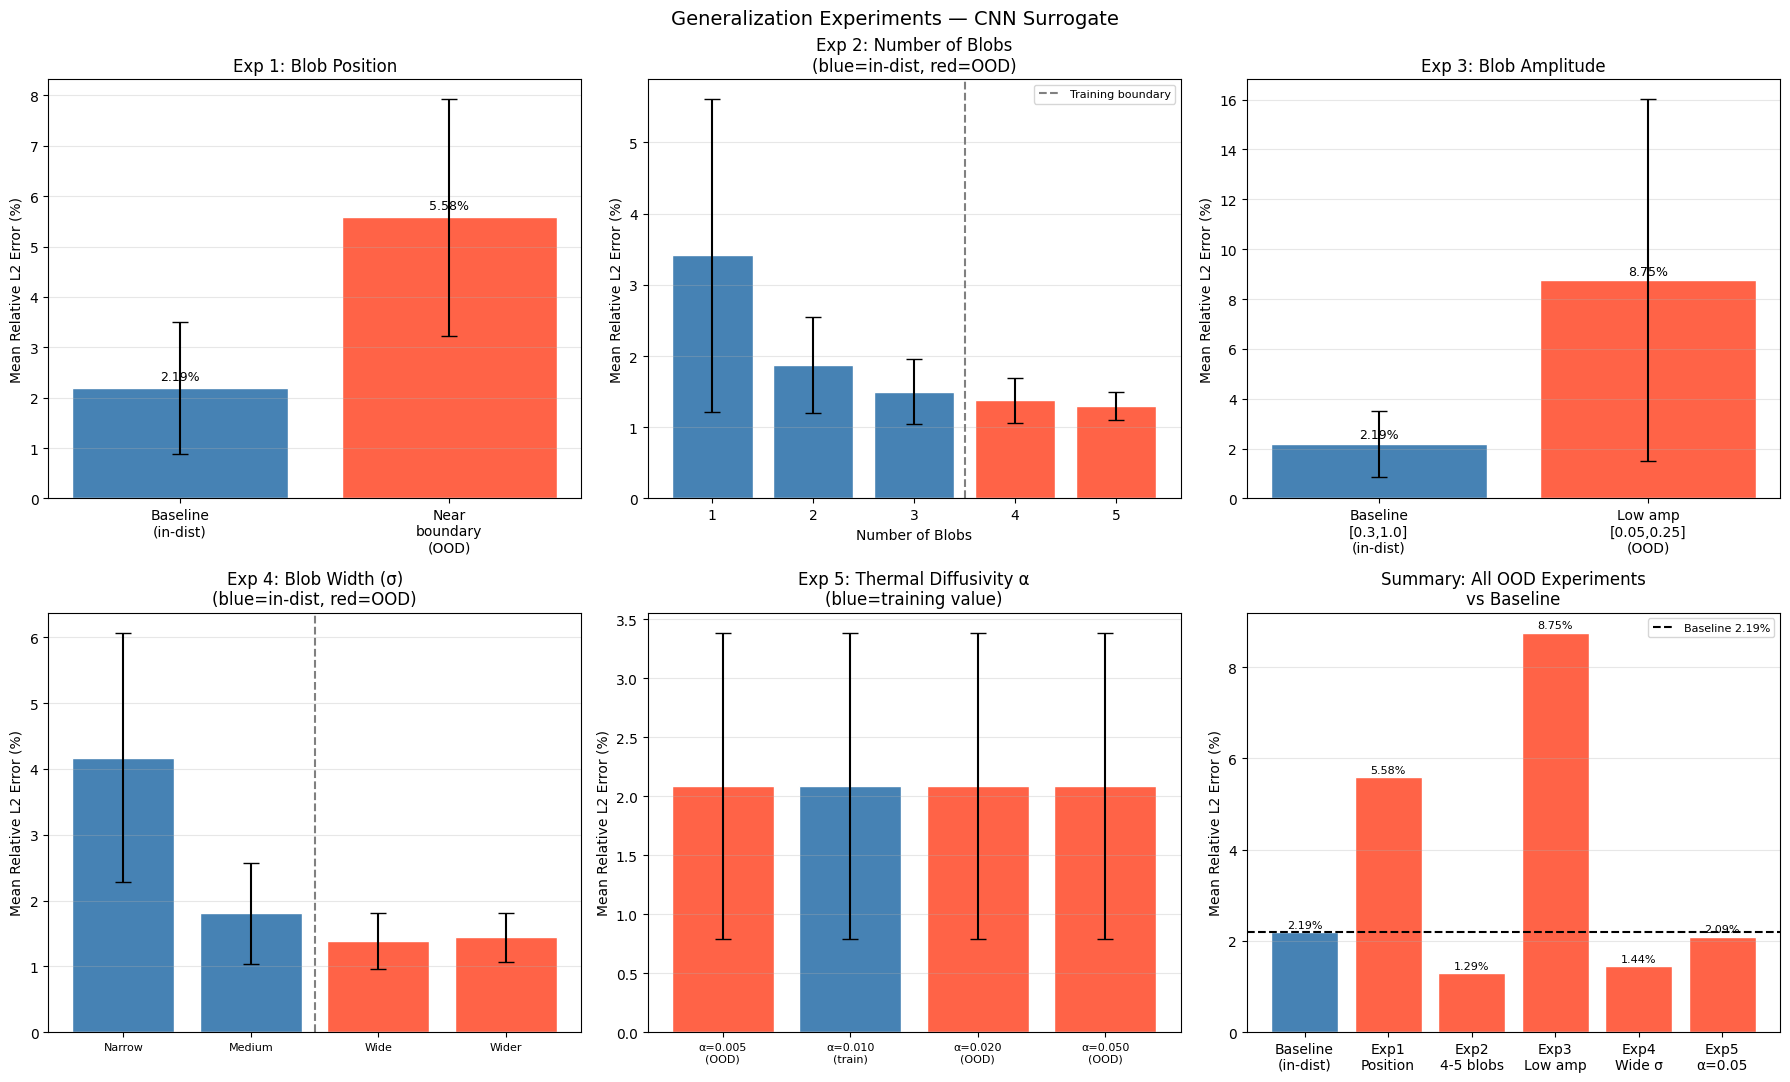

✓ Saved figures/milestone9_generalization.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# ── Plot 1: Experiment 1 — position ──────────────────
ax = axes[0, 0]
labels_ = ["Baseline\n(in-dist)", "Near\nboundary\n(OOD)"]
means_  = [
    np.mean(baseline_results["rel_l2"]) * 100,
    np.mean(exp1_results["rel_l2"]) * 100,
]
stds_   = [
    np.std(baseline_results["rel_l2"]) * 100,
    np.std(exp1_results["rel_l2"]) * 100,
]
colors_ = ["steelblue", "tomato"]
bars    = ax.bar(labels_, means_, yerr=stds_, color=colors_,
                 capsize=6, edgecolor="white")
ax.set_ylabel("Mean Relative L2 Error (%)")
ax.set_title("Exp 1: Blob Position")
ax.grid(True, alpha=0.3, axis="y")
for bar, m in zip(bars, means_):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{m:.2f}%", ha="center", va="bottom", fontsize=9)

# ── Plot 2: Experiment 2 — number of blobs ───────────
ax = axes[0, 1]
nb_vals  = list(results_by_nblobs.keys())
nb_means = [np.mean(results_by_nblobs[nb]["rel_l2"])*100 for nb in nb_vals]
nb_stds  = [np.std(results_by_nblobs[nb]["rel_l2"])*100  for nb in nb_vals]
nb_cols  = ["steelblue"]*3 + ["tomato"]*2
bars2    = ax.bar([str(nb) for nb in nb_vals], nb_means,
                  yerr=nb_stds, color=nb_cols, capsize=6, edgecolor="white")
ax.set_xlabel("Number of Blobs")
ax.set_ylabel("Mean Relative L2 Error (%)")
ax.set_title("Exp 2: Number of Blobs\n(blue=in-dist, red=OOD)")
ax.grid(True, alpha=0.3, axis="y")
ax.axvline(2.5, color="gray", linestyle="--", linewidth=1.5,
           label="Training boundary")
ax.legend(fontsize=8)

# ── Plot 3: Experiment 3 — amplitude ─────────────────
ax = axes[0, 2]
amp_labels = ["Baseline\n[0.3,1.0]\n(in-dist)", "Low amp\n[0.05,0.25]\n(OOD)"]
amp_means  = [
    np.mean(baseline_results["rel_l2"])*100,
    np.mean(exp3_results["rel_l2"])*100,
]
amp_stds   = [
    np.std(baseline_results["rel_l2"])*100,
    np.std(exp3_results["rel_l2"])*100,
]
bars3 = ax.bar(amp_labels, amp_means, yerr=amp_stds,
               color=["steelblue","tomato"], capsize=6, edgecolor="white")
ax.set_ylabel("Mean Relative L2 Error (%)")
ax.set_title("Exp 3: Blob Amplitude")
ax.grid(True, alpha=0.3, axis="y")
for bar, m in zip(bars3, amp_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{m:.2f}%", ha="center", va="bottom", fontsize=9)

# ── Plot 4: Experiment 4 — blob width ────────────────
ax = axes[1, 0]
sigma_labels = list(results_by_sigma.keys())
sigma_means  = [np.mean(results_by_sigma[l]["rel_l2"])*100
                for l in sigma_labels]
sigma_stds   = [np.std(results_by_sigma[l]["rel_l2"])*100
                for l in sigma_labels]
sigma_cols   = ["steelblue", "steelblue", "tomato", "tomato"]
bars4 = ax.bar(range(len(sigma_labels)), sigma_means,
               yerr=sigma_stds, color=sigma_cols, capsize=6, edgecolor="white")
ax.set_xticks(range(len(sigma_labels)))
ax.set_xticklabels([l.split()[0] for l in sigma_labels], fontsize=8)
ax.set_ylabel("Mean Relative L2 Error (%)")
ax.set_title("Exp 4: Blob Width (σ)\n(blue=in-dist, red=OOD)")
ax.grid(True, alpha=0.3, axis="y")
ax.axvline(1.5, color="gray", linestyle="--", linewidth=1.5)

# ── Plot 5: Experiment 5 — thermal diffusivity ───────
ax = axes[1, 1]
alpha_labels = list(results_by_alpha.keys())
alpha_means  = [np.mean(results_by_alpha[l]["rel_l2"])*100
                for l in alpha_labels]
alpha_stds   = [np.std(results_by_alpha[l]["rel_l2"])*100
                for l in alpha_labels]
alpha_cols   = ["tomato", "steelblue", "tomato", "tomato"]
bars5 = ax.bar(range(len(alpha_labels)), alpha_means,
               yerr=alpha_stds, color=alpha_cols, capsize=6, edgecolor="white")
ax.set_xticks(range(len(alpha_labels)))
ax.set_xticklabels(["α=0.005\n(OOD)", "α=0.010\n(train)",
                    "α=0.020\n(OOD)", "α=0.050\n(OOD)"], fontsize=8)
ax.set_ylabel("Mean Relative L2 Error (%)")
ax.set_title("Exp 5: Thermal Diffusivity α\n(blue=training value)")
ax.grid(True, alpha=0.3, axis="y")

# ── Plot 6: Summary comparison ───────────────────────
ax = axes[1, 2]
summary_labels = [
    "Baseline\n(in-dist)",
    "Exp1\nPosition",
    "Exp2\n4-5 blobs",
    "Exp3\nLow amp",
    "Exp4\nWide σ",
    "Exp5\nα=0.05",
]
summary_means = [
    np.mean(baseline_results["rel_l2"])*100,
    np.mean(exp1_results["rel_l2"])*100,
    np.mean(results_by_nblobs[5]["rel_l2"])*100,
    np.mean(exp3_results["rel_l2"])*100,
    np.mean(list(results_by_sigma.values())[-1]["rel_l2"])*100,
    np.mean(results_by_alpha[list(alpha_labels)[-1]]["rel_l2"])*100,
]
summary_cols = ["steelblue"] + ["tomato"]*5
bars6 = ax.bar(summary_labels, summary_means,
               color=summary_cols, edgecolor="white")
ax.axhline(baseline_rel_l2, color="black", linestyle="--",
           linewidth=1.5, label=f"Baseline {baseline_rel_l2:.2f}%")
ax.set_ylabel("Mean Relative L2 Error (%)")
ax.set_title("Summary: All OOD Experiments\nvs Baseline")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis="y")
for bar, m in zip(bars6, summary_means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f"{m:.2f}%", ha="center", va="bottom", fontsize=8)

plt.suptitle("Generalization Experiments — CNN Surrogate", fontsize=14)
plt.tight_layout()
plt.savefig("../figures/milestone9_generalization.png", dpi=150)
plt.show()
print("✓ Saved figures/milestone9_generalization.png")

Cell 10 — Visual comparison: in-dist vs OOD sample

Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567


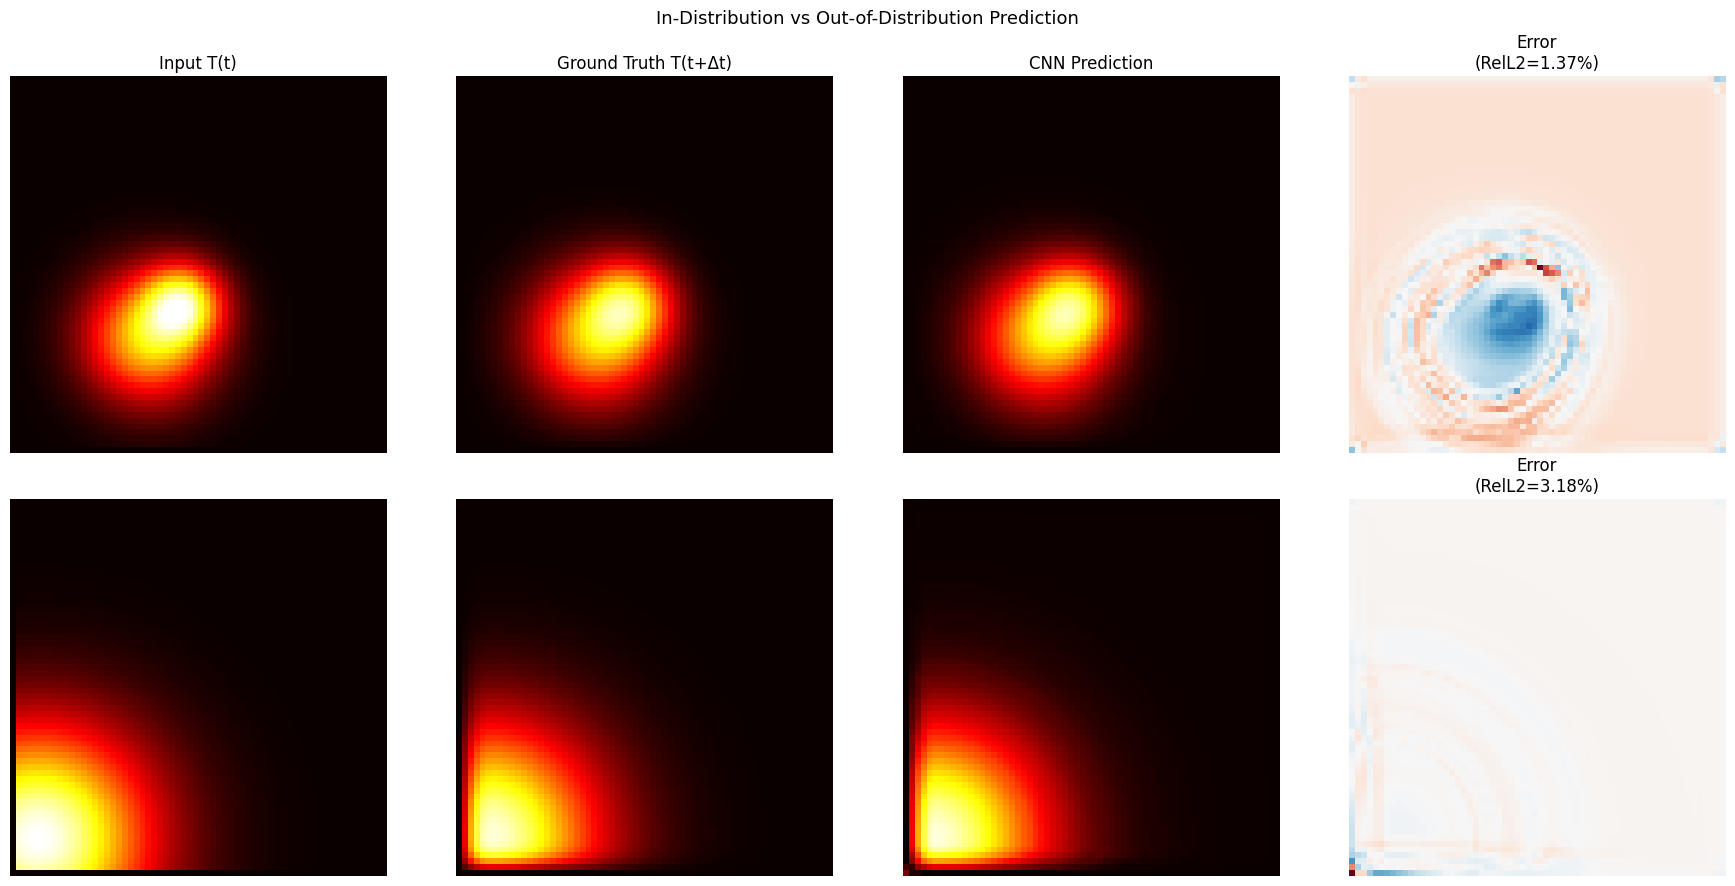

In [10]:
# pick one in-distribution and one OOD example
# and show input, ground truth, CNN prediction, error side by side

rng_vis = np.random.default_rng(3000)

# in-distribution
ic_in = make_blobs(1, rng_vis,
    cx_range=(0.2, 0.8), cy_range=(0.2, 0.8),
    amp_range=(0.4, 0.9), sigma_range=(0.06, 0.13),
    n_blobs=2)[0]

# out-of-distribution: 5 blobs, near boundary
ic_ood = make_blobs(1, rng_vis,
    cx_range=(0.05, 0.15), cy_range=(0.05, 0.15),
    amp_range=(0.05, 0.20), sigma_range=(0.18, 0.25),
    n_blobs=5)[0]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
row_labels = ["In-Distribution", "Out-of-Distribution\n(5 blobs, boundary, low amp, wide σ)"]

for row, (ic, row_label) in enumerate(zip([ic_in, ic_ood], row_labels)):
    snaps, _, _, _ = run_simulation(ic, alpha, dx, n_steps=stride, save_every=stride)
    target = snaps[-1]

    inp_t  = torch.from_numpy(ic).float().unsqueeze(0).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(inp_t).squeeze().cpu().numpy()
    err    = pred - target

    vmax = max(ic.max(), target.max(), pred.max())

    axes[row, 0].imshow(ic,     origin="lower", cmap="hot", vmin=0, vmax=vmax)
    axes[row, 0].set_title("Input T(t)"          if row==0 else "")
    axes[row, 0].set_ylabel(row_label, fontsize=9)

    axes[row, 1].imshow(target, origin="lower", cmap="hot", vmin=0, vmax=vmax)
    axes[row, 1].set_title("Ground Truth T(t+Δt)" if row==0 else "")

    axes[row, 2].imshow(pred,   origin="lower", cmap="hot", vmin=0, vmax=vmax)
    axes[row, 2].set_title("CNN Prediction"       if row==0 else "")

    err_sc = max(np.abs(err).max(), 1e-6)
    axes[row, 3].imshow(err, origin="lower", cmap="RdBu_r",
                        vmin=-err_sc, vmax=err_sc)
    axes[row, 3].set_title(f"Error\n(RelL2={relative_l2(pred,target)*100:.2f}%)"
                           if row==0 else
                           f"Error\n(RelL2={relative_l2(pred,target)*100:.2f}%)")

    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("In-Distribution vs Out-of-Distribution Prediction", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/milestone9_indist_vs_ood.png", dpi=150)
plt.show()

Cell 11 — Save results

In [11]:
import json

gen_results = {
    "baseline_rel_l2_mean" : float(np.mean(baseline_results["rel_l2"]) * 100),
    "baseline_rel_l2_std"  : float(np.std(baseline_results["rel_l2"])  * 100),
    "exp1_near_boundary"   : {
        "rel_l2_mean" : float(np.mean(exp1_results["rel_l2"]) * 100),
        "rel_l2_std"  : float(np.std(exp1_results["rel_l2"])  * 100),
        "degradation" : float(degradation_e1),
        "type"        : "extrapolation",
    },
    "exp2_n_blobs" : {
        str(nb): {
            "rel_l2_mean": float(np.mean(results_by_nblobs[nb]["rel_l2"])*100),
            "rel_l2_std" : float(np.std(results_by_nblobs[nb]["rel_l2"])*100),
            "in_dist"    : nb <= 3,
        }
        for nb in results_by_nblobs
    },
    "exp3_low_amplitude" : {
        "rel_l2_mean" : float(np.mean(exp3_results["rel_l2"]) * 100),
        "rel_l2_std"  : float(np.std(exp3_results["rel_l2"])  * 100),
        "degradation" : float(degradation_e3),
        "type"        : "extrapolation",
    },
    "exp4_blob_width" : {
        label: {
            "rel_l2_mean": float(np.mean(results_by_sigma[label]["rel_l2"])*100),
            "rel_l2_std" : float(np.std(results_by_sigma[label]["rel_l2"])*100),
        }
        for label in results_by_sigma
    },
    "exp5_alpha" : {
        label: {
            "rel_l2_mean": float(np.mean(results_by_alpha[label]["rel_l2"])*100),
            "rel_l2_std" : float(np.std(results_by_alpha[label]["rel_l2"])*100),
        }
        for label in results_by_alpha
    },
}

with open("../results/generalization_results.json", "w") as f:
    json.dump(gen_results, f, indent=2)

print("✓ Saved results/generalization_results.json")

# ── print clean summary table ─────────────────────────
print("\n" + "="*60)
print("TABLE 3 — GENERALIZATION EXPERIMENT SUMMARY")
print("="*60)
print(f"{'Experiment':<35} {'RelL2 Mean':>12} {'Type':>16}")
print("-"*60)
print(f"{'Baseline (in-distribution)':<35} "
      f"{np.mean(baseline_results['rel_l2'])*100:>11.3f}% {'interpolation':>16}")
print(f"{'Exp1: Near-boundary position':<35} "
      f"{np.mean(exp1_results['rel_l2'])*100:>11.3f}% {'extrapolation':>16}")
print(f"{'Exp2: 4 blobs (max trained=3)':<35} "
      f"{np.mean(results_by_nblobs[4]['rel_l2'])*100:>11.3f}% {'extrapolation':>16}")
print(f"{'Exp2: 5 blobs (max trained=3)':<35} "
      f"{np.mean(results_by_nblobs[5]['rel_l2'])*100:>11.3f}% {'extrapolation':>16}")
print(f"{'Exp3: Low amplitude [0.05,0.25]':<35} "
      f"{np.mean(exp3_results['rel_l2'])*100:>11.3f}% {'extrapolation':>16}")
print(f"{'Exp4: Wide blobs [0.20,0.28]':<35} "
      f"{np.mean(list(results_by_sigma.values())[-1]['rel_l2'])*100:>11.3f}% "
      f"{'extrapolation':>16}")
print(f"{'Exp5: alpha=0.005 (half)':<35} "
      f"{np.mean(results_by_alpha[list(alpha_labels)[0]]['rel_l2'])*100:>11.3f}% "
      f"{'extrapolation':>16}")
print(f"{'Exp5: alpha=0.050 (5x faster)':<35} "
      f"{np.mean(results_by_alpha[list(alpha_labels)[-1]]['rel_l2'])*100:>11.3f}% "
      f"{'extrapolation':>16}")
print("="*60)

✓ Saved results/generalization_results.json

TABLE 3 — GENERALIZATION EXPERIMENT SUMMARY
Experiment                            RelL2 Mean             Type
------------------------------------------------------------
Baseline (in-distribution)                2.188%    interpolation
Exp1: Near-boundary position              5.580%    extrapolation
Exp2: 4 blobs (max trained=3)             1.378%    extrapolation
Exp2: 5 blobs (max trained=3)             1.295%    extrapolation
Exp3: Low amplitude [0.05,0.25]           8.752%    extrapolation
Exp4: Wide blobs [0.20,0.28]              1.444%    extrapolation
Exp5: alpha=0.005 (half)                  2.090%    extrapolation
Exp5: alpha=0.050 (5x faster)             2.090%    extrapolation


In [12]:
from heat_solver import run_simulation

T0_test = base_ics_e5[0]
dx_     = 1.0 / (N - 1)

for a in [0.005, 0.010, 0.050]:
    snaps, _, _, _ = run_simulation(T0_test, a, dx_,
                                    n_steps=stride, save_every=stride)
    print(f"alpha={a:.3f}:  "
          f"target mean={snaps[-1].mean():.6f}  "
          f"target max={snaps[-1].max():.6f}")

Grid spacing     dx = 0.015873
Time step        dt = 0.011338
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.1134
alpha=0.005:  target mean=0.009895  target max=0.559064
Grid spacing     dx = 0.015873
Time step        dt = 0.005669
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0567
alpha=0.010:  target mean=0.009895  target max=0.559064
Grid spacing     dx = 0.015873
Time step        dt = 0.001134
Fourier number    r = 0.2250  (must be <= 0.25)
Total sim time      = 0.0113
alpha=0.050:  target mean=0.009895  target max=0.559064


In [13]:
# Fix: use a FIXED dt across all alpha values
# so different alpha values produce genuinely different amounts of diffusion

fixed_dt = 0.005669   # the dt corresponding to alpha=0.01 (training value)

alpha_test_values = [0.005, 0.010, 0.020, 0.050]
results_by_alpha  = {}

rng_e5 = np.random.default_rng(2005)
base_ics_e5 = make_blobs(
    200, rng_e5,
    cx_range=(0.2, 0.8), cy_range=(0.2, 0.8),
    amp_range=(0.3, 1.0), sigma_range=(0.04, 0.15),
    n_blobs_range=(1, 3),
)

for alpha_test in alpha_test_values:

    # check stability with fixed dt
    r_test = alpha_test * fixed_dt / dx**2
    if r_test > 0.25:
        print(f"alpha={alpha_test}: UNSTABLE with fixed dt "
              f"(r={r_test:.3f} > 0.25), skipping.")
        continue

    rel_l2_vals = []

    for T0 in base_ics_e5:
        # manually run stride steps with fixed_dt
        T = T0.copy()
        for _ in range(stride):
            T_new = T.copy()
            T_new[1:-1, 1:-1] = (
                T[1:-1, 1:-1]
                + r_test * (
                    T[2:,   1:-1]
                  + T[:-2,  1:-1]
                  + T[1:-1, 2:]
                  + T[1:-1, :-2]
                  - 4 * T[1:-1, 1:-1]
                )
            )
            T = apply_dirichlet_zero(T_new)
        target = T

        # CNN prediction — always assumes alpha=0.01
        inp  = torch.from_numpy(T0).float().unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(inp).squeeze().cpu().numpy()

        rel_l2_vals.append(relative_l2(pred, target))

    mean_err = np.mean(rel_l2_vals) * 100
    std_err  = np.std(rel_l2_vals)  * 100
    in_dist  = alpha_test == 0.01

    results_by_alpha[f"alpha={alpha_test}"] = {
        "rel_l2_mean" : mean_err,
        "rel_l2_std"  : std_err,
        "r_value"     : r_test,
        "in_dist"     : in_dist,
    }

    print(f"alpha={alpha_test:.3f}  r={r_test:.4f}  "
          f"({'IN' if in_dist else 'OOD'}):  "
          f"RelL2 = {mean_err:.3f}% ± {std_err:.3f}%")

alpha=0.005  r=0.1125  (OOD):  RelL2 = 5.289% ± 2.508%
alpha=0.010  r=0.2250  (IN):  RelL2 = 2.090% ± 1.298%
alpha=0.02: UNSTABLE with fixed dt (r=0.450 > 0.25), skipping.
alpha=0.05: UNSTABLE with fixed dt (r=1.125 > 0.25), skipping.


In [14]:
# Add this cell

target_physical_time = stride * fixed_dt   # 0.05669 — same as training

print(f"Target physical time per CNN step: {target_physical_time:.5f}")
print()

alpha_extended = [0.005, 0.010, 0.020, 0.050]
results_by_alpha_fixed = {}

rng_e5b = np.random.default_rng(2005)
base_ics_e5b = make_blobs(
    200, rng_e5b,
    cx_range      = (0.2, 0.8),
    cy_range      = (0.2, 0.8),
    amp_range     = (0.3, 1.0),
    sigma_range   = (0.04, 0.15),
    n_blobs_range = (1, 3),
)

for alpha_test in alpha_extended:

    # compute stable dt for this alpha
    dx_      = 1.0 / (N - 1)
    dt_safe  = 0.9 * dx_**2 / (4 * alpha_test)   # safety=0.9
    r_safe   = alpha_test * dt_safe / dx_**2

    # compute how many steps needed to cover target_physical_time
    n_steps_needed = max(1, int(np.ceil(target_physical_time / dt_safe)))
    actual_time    = n_steps_needed * dt_safe

    print(f"alpha={alpha_test:.3f}:  "
          f"dt={dt_safe:.6f}  r={r_safe:.4f}  "
          f"steps={n_steps_needed}  "
          f"physical_time={actual_time:.5f}")

    rel_l2_vals = []

    for T0 in base_ics_e5b:

        # run solver for n_steps_needed with stable dt
        T = T0.copy()
        for _ in range(n_steps_needed):
            T_new = T.copy()
            T_new[1:-1, 1:-1] = (
                T[1:-1, 1:-1]
                + r_safe * (
                    T[2:,   1:-1]
                  + T[:-2,  1:-1]
                  + T[1:-1, 2:]
                  + T[1:-1, :-2]
                  - 4 * T[1:-1, 1:-1]
                )
            )
            T = apply_dirichlet_zero(T_new)
        target = T

        # CNN prediction — always predicts as if alpha=0.01
        inp  = torch.from_numpy(T0).float().unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(inp).squeeze().cpu().numpy()

        rel_l2_vals.append(relative_l2(pred, target))

    mean_err = np.mean(rel_l2_vals) * 100
    std_err  = np.std(rel_l2_vals)  * 100
    in_dist  = "IN-DIST" if alpha_test == 0.01 else "OOD"

    results_by_alpha_fixed[f"alpha={alpha_test}"] = {
        "rel_l2_mean"   : mean_err,
        "rel_l2_std"    : std_err,
        "alpha"         : alpha_test,
        "dt_used"       : dt_safe,
        "n_steps_used"  : n_steps_needed,
        "physical_time" : actual_time,
        "in_dist"       : alpha_test == 0.01,
    }

    print(f"  ({in_dist}):  RelL2 = {mean_err:.3f}% ± {std_err:.3f}%")
    print()

Target physical time per CNN step: 0.05669

alpha=0.005:  dt=0.011338  r=0.2250  steps=6  physical_time=0.06803
  (OOD):  RelL2 = 4.415% ± 2.050%

alpha=0.010:  dt=0.005669  r=0.2250  steps=11  physical_time=0.06236
  (IN-DIST):  RelL2 = 2.124% ± 1.457%

alpha=0.020:  dt=0.002834  r=0.2250  steps=21  physical_time=0.05952
  (OOD):  RelL2 = 8.757% ± 4.875%

alpha=0.050:  dt=0.001134  r=0.2250  steps=51  physical_time=0.05782
  (OOD):  RelL2 = 28.383% ± 14.160%

